In [4]:
import shutil
import os

zip_path = '/content/Plant_leaf_diseases_dataset_without_augmentation.zip'
extract_path = '/content/plant_leaf_disease_dataset'

try:
    shutil.unpack_archive(zip_path, extract_path)
    print(f" Dataset extracted to: {extract_path}")
except Exception as e:
    print("Extraction error:", e)


 Dataset extracted to: /content/plant_leaf_disease_dataset


In [5]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

data_dir = '/content/plant_leaf_disease_dataset/Plant_leave_diseases_dataset_without_augmentation'
csv_output = '/content/plant_disease_severity.csv'

def get_severity(ratio):
    if ratio < 0.1:
        return 'Mild'
    elif ratio < 0.4:
        return 'Moderate'
    else:
        return 'Severe'

def analyze_leaf(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None

    img = cv2.resize(img, (256, 256))
    hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    green_min = np.array([25, 40, 40])
    green_max = np.array([90, 255, 255])
    healthy_mask = cv2.inRange(hsv_img, green_min, green_max)
    healthy_area = np.count_nonzero(healthy_mask)

    affected_mask = cv2.bitwise_not(healthy_mask)
    affected_area = np.count_nonzero(affected_mask)

    if healthy_area + affected_area == 0:
        return None

    ratio = affected_area / (healthy_area + affected_area)
    return get_severity(ratio)

entries = []

for label in tqdm(os.listdir(data_dir), desc='Analyzing'):
    folder = os.path.join(data_dir, label)
    if not os.path.isdir(folder):
        continue

    for file in os.listdir(folder):
        path = os.path.join(folder, file)

        if 'healthy' in label.lower():
            severity = 'Mild'
        else:
            severity = analyze_leaf(path)

        if severity:
            entries.append({
                'image_path': path,
                'disease': label,
                'severity': severity
            })

df = pd.DataFrame(entries)
df.to_csv(csv_output, index=False)
print(f"Saved output to: {csv_output}")


Analyzing: 100%|██████████| 39/39 [00:33<00:00,  1.17it/s]


Saved output to: /content/plant_disease_severity.csv


In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

df = pd.read_csv('/content/plant_disease_severity.csv')

disease_encoder = LabelEncoder()
df['disease_label'] = disease_encoder.fit_transform(df['disease'])

severity_encoder = LabelEncoder()
df['severity_label'] = severity_encoder.fit_transform(df['severity'])

train_data, temp_data = train_test_split(
    df, test_size=0.3, stratify=df['disease_label'], random_state=42
)

val_data, test_data = train_test_split(
    temp_data, test_size=0.5, stratify=temp_data['disease_label'], random_state=42
)

print(len(train_data), len(val_data), len(test_data))


38813 8317 8318


In [7]:
import cv2
import numpy as np
from tensorflow.keras.utils import Sequence, to_categorical

IMG_SIZE = (256, 256)
BATCH = 32

class DualLabelGenerator(Sequence):
    def __init__(self, dataframe, batch_size, image_size, one_hot=True):
        self.data = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.image_size = image_size
        self.one_hot = one_hot

    def __len__(self):
        return int(np.ceil(len(self.data) / self.batch_size))

    def __getitem__(self, idx):
        batch = self.data.iloc[idx * self.batch_size:(idx + 1) * self.batch_size]
        images, disease_targets, severity_targets = [], [], []

        for _, row in batch.iterrows():
            img = cv2.imread(row['image_path'])
            if img is None:
                continue
            img = cv2.resize(img, self.image_size)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            disease_targets.append(row['disease_label'])
            severity_targets.append(row['severity_label'])

        if len(images) == 0:
            return self.__getitem__((idx + 1) % self.__len__())

        images = np.array(images) / 255.0

        if self.one_hot:
            disease_targets = to_categorical(disease_targets, num_classes=len(disease_encoder.classes_))
            severity_targets = to_categorical(severity_targets, num_classes=len(severity_encoder.classes_))
        else:
            disease_targets = np.array(disease_targets)
            severity_targets = np.array(severity_targets)

        return images, (disease_targets, severity_targets)

train_loader = DualLabelGenerator(train_data, BATCH, IMG_SIZE, one_hot=True)
val_loader = DualLabelGenerator(val_data, BATCH, IMG_SIZE, one_hot=True)
test_loader = DualLabelGenerator(test_data, BATCH, IMG_SIZE, one_hot=False)


In [8]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base = MobileNetV2(include_top=False, weights='imagenet', input_shape=(256, 256, 3))
base.trainable = False

features = GlobalAveragePooling2D()(base.output)
features = Dropout(0.3)(features)

disease_pred = Dense(len(disease_encoder.classes_), activation='softmax', name='disease_output')(features)
severity_pred = Dense(len(severity_encoder.classes_), activation='softmax', name='severity_output')(features)

multi_task_model = Model(inputs=base.input, outputs=[disease_pred, severity_pred])

multi_task_model.compile(
    optimizer=Adam(),
    loss={
        'disease_output': 'categorical_crossentropy',
        'severity_output': 'categorical_crossentropy'
    },
    metrics={
        'disease_output': 'accuracy',
        'severity_output': 'accuracy'
    }
)

multi_task_model.summary()


<ipython-input-8-a4e14106cd4f>:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(include_top=False, weights='imagenet', input_shape=(256, 256, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 2,311,786 (8.82 MB)

 Trainable params: 53,802 (210.16 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('mobilenetv2_best_model.keras', monitor='val_loss', save_best_only=True)
]

history = multi_task_model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=10,
    callbacks=callbacks_list,
    verbose=1
)


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1213/1213 ━━━━━━━━━━━━━━━━━━━━ 138s 100ms/step - disease_output_accuracy: 0.7436 - disease_output_loss: 1.0131 - loss: 1.3635 - severity_output_accuracy: 0.8644 - severity_output_loss: 0.3512 - val_disease_output_accuracy: 0.9370 - val_disease_output_loss: 0.2170 - val_loss: 0.3919 - val_severity_output_accuracy: 0.9350 - val_severity_output_loss: 0.1748
Epoch 2/10
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 103s 85ms/step - disease_output_accuracy: 0.9267 - disease_output_loss: 0.2381 - loss: 0.4317 - severity_output_accuracy: 0.9267 - severity_output_loss: 0.1937 - val_disease_output_accuracy: 0.9429 - val_disease_output_loss: 0.1805 - val_loss: 0.3307 - val_severity_output_accuracy: 0.9484 - val_severity_output_loss: 0.1500
Epoch 3/10
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 104s 86ms/step - disease_output_accuracy: 0.9463 - disease_output_loss: 0.1729 - loss: 0.3512 - severity_output_accuracy: 0.9313 - severity_output_loss: 0.1783 - val_disease_output_accuracy: 0.9543 - val_disease_output_loss: 0.1502 - 

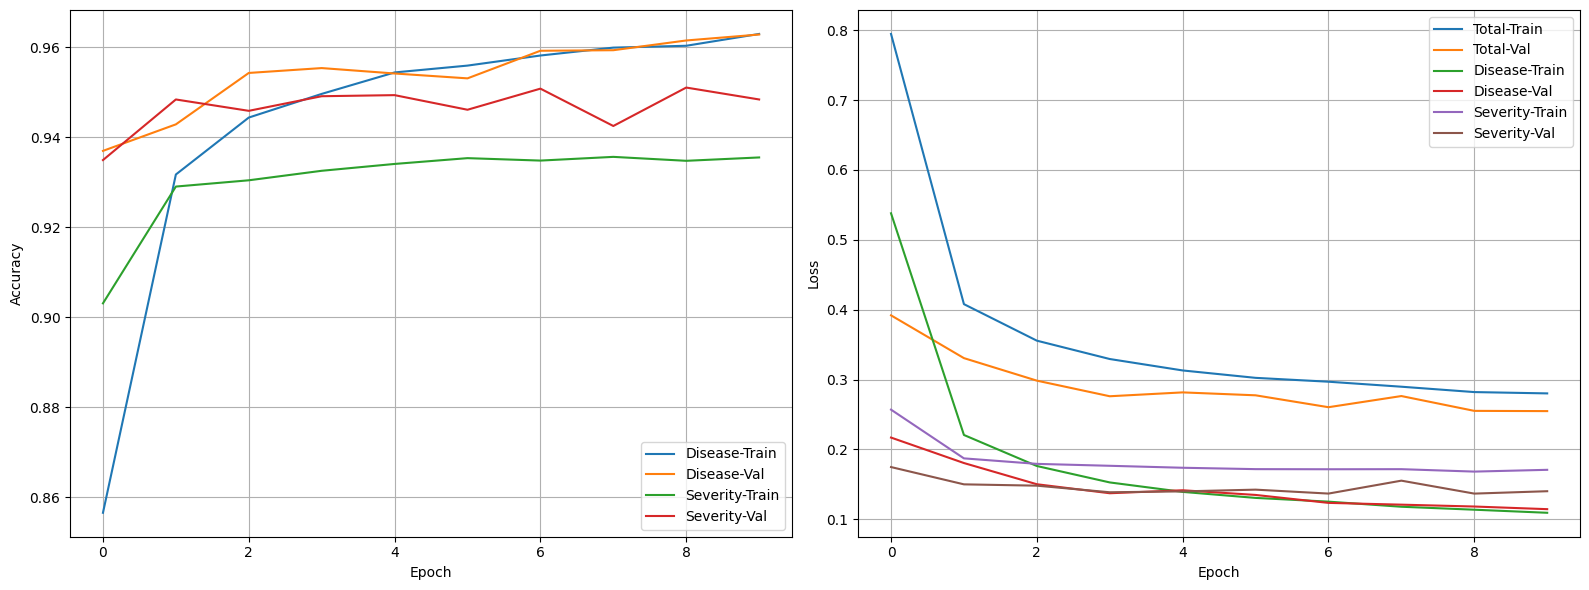

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['disease_output_accuracy'])
plt.plot(history.history['val_disease_output_accuracy'])
plt.plot(history.history['severity_output_accuracy'])
plt.plot(history.history['val_severity_output_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Disease-Train', 'Disease-Val', 'Severity-Train', 'Severity-Val'])
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['disease_output_loss'])
plt.plot(history.history['val_disease_output_loss'])
plt.plot(history.history['severity_output_loss'])
plt.plot(history.history['val_severity_output_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Total-Train', 'Total-Val', 'Disease-Train', 'Disease-Val', 'Severity-Train', 'Severity-Val'])
plt.grid()

plt.tight_layout()
plt.show()


In [11]:
import numpy as np
import cv2
from tensorflow.keras.models import load_model


model = load_model('/content/mobilenetv2_best_model.keras')


meta = {
    "disease_classes": disease_encoder.classes_,
    "severity_classes": severity_encoder.classes_
}


def preprocess_image(path):
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Image not found: {path}")
    img = cv2.resize(img, (256, 256))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0
    return np.expand_dims(img, axis=0)


def predict_image(path):
    image = preprocess_image(path)
    disease_pred, severity_pred = model.predict(image, verbose=0)
    disease = meta["disease_classes"][np.argmax(disease_pred)]
    severity = meta["severity_classes"][np.argmax(severity_pred)]
    return disease, severity


img_path = '/content/plant_leaf_disease_dataset/Plant_leave_diseases_dataset_without_augmentation/Potato___Early_blight/image (1).JPG'
result = predict_image(img_path)
print("Predicted:", result)


Predicted: ('Potato___Early_blight', 'Severe')


In [12]:
from tensorflow.keras.utils import to_categorical


X_test = np.array([preprocess_image(path)[0] for path in test_data['image_path']])
y_test_disease = np.array(test_data['disease_label'])
y_test_severity = np.array(test_data['severity_label'])

y_test_disease_cat = to_categorical(y_test_disease, num_classes=len(disease_encoder.classes_))
y_test_severity_cat = to_categorical(y_test_severity, num_classes=len(severity_encoder.classes_))


In [13]:
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report
import numpy as np


X_test = np.array([preprocess_image(path)[0] for path in test_data['image_path']])


y_true_disease = np.array(test_data['disease_label'])
y_true_severity = np.array(test_data['severity_label'])


y_test_disease_cat = to_categorical(y_true_disease, num_classes=len(disease_encoder.classes_))
y_test_severity_cat = to_categorical(y_true_severity, num_classes=len(severity_encoder.classes_))


results = multi_task_model.evaluate(X_test, [y_test_disease_cat, y_test_severity_cat], verbose=1)
print(f"\nDisease Test Accuracy:  {results[3]:.4f}")
print(f"Severity Test Accuracy: {results[4]:.4f}")


disease_preds, severity_preds = multi_task_model.predict(X_test, verbose=1)
y_pred_disease = np.argmax(disease_preds, axis=1)
y_pred_severity = np.argmax(severity_preds, axis=1)


print("\n Disease Classification Report:")
print(classification_report(y_true_disease, y_pred_disease, target_names=disease_encoder.classes_))

print("\n Severity Classification Report:")
print(classification_report(y_true_severity, y_pred_severity, target_names=severity_encoder.classes_))


260/260 ━━━━━━━━━━━━━━━━━━━━ 19s 56ms/step - disease_output_accuracy: 0.9628 - disease_output_loss: 0.1116 - loss: 0.2493 - severity_output_accuracy: 0.9474 - severity_output_loss: 0.1377

Disease Test Accuracy:  0.9603
Severity Test Accuracy: 0.9467
260/260 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step

 Disease Classification Report:
                                               precision    recall  f1-score   support

                           Apple___Apple_scab       0.97      0.95      0.96        94
                            Apple___Black_rot       0.98      0.99      0.98        93
                     Apple___Cedar_apple_rust       1.00      0.98      0.99        41
                              Apple___healthy       0.99      0.99      0.99       247
                    Background_without_leaves       1.00      1.00      1.00       171
                          Blueberry___healthy       0.99      0.99      0.99       226
                      Cherry___Powdery_mildew       1.00      0.

In [14]:
import pickle
from tensorflow.keras.models import save_model

save_model(multi_task_model, "mobilenetv2_final_model.keras")

metadata = {
    "model_path": "mobilenetv2_final_model.keras",
    "disease_classes": disease_encoder.classes_.tolist(),
    "severity_classes": severity_encoder.classes_.tolist()
}

with open("mobilenetv2_metadata.pkl", "wb") as f:
    pickle.dump(metadata, f)


In [15]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras import regularizers

resnet50_base = ResNet50(include_top=False, weights='imagenet', input_shape=(256,256,3))

for layer in resnet50_base.layers[:140]:
    layer.trainable = False
for layer in resnet50_base.layers[140:]:
    layer.trainable = True

features = GlobalAveragePooling2D()(resnet50_base.output)
features = Dropout(0.5)(features)

disease_pred = Dense(
    len(disease_encoder.classes_), activation='softmax',
    kernel_regularizer=regularizers.l2(0.01), name='disease_output')(features)

severity_pred = Dense(
    len(severity_encoder.classes_), activation='softmax',
    kernel_regularizer=regularizers.l2(0.01), name='severity_output')(features)

resnet50_model = Model(inputs=resnet50_base.input, outputs=[disease_pred, severity_pred])

resnet50_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss={
        'disease_output': CategoricalCrossentropy(label_smoothing=0.05),
        'severity_output': CategoricalCrossentropy(label_smoothing=0.03)
    },
    loss_weights={'disease_output': 2.0, 'severity_output': 1.0},
    metrics={'disease_output': 'accuracy', 'severity_output': 'accuracy'}
)

resnet50_model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 23,673,770 (90.31 MB)

 Trainable params: 15,064,106 (57.47 MB)

 Non-trainable params: 8,609,664 (32.84 MB)

In [16]:
resnet50_callbacks = [
    EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
    ModelCheckpoint('resnet50_finetuned.keras', monitor='val_loss', save_best_only=True)
]

resnet50_history = resnet50_model.fit(
    train_loader, validation_data=val_loader,
    epochs=10, callbacks=resnet50_callbacks, verbose=1
)


Epoch 1/10
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 139s 97ms/step - disease_output_accuracy: 0.3531 - disease_output_loss: 2.6172 - loss: 6.6958 - severity_output_accuracy: 0.7494 - severity_output_loss: 0.6423 - val_disease_output_accuracy: 0.6608 - val_disease_output_loss: 1.4993 - val_loss: 4.2296 - val_severity_output_accuracy: 0.8605 - val_severity_output_loss: 0.4233
Epoch 2/10
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 101s 83ms/step - disease_output_accuracy: 0.6619 - disease_output_loss: 1.4724 - loss: 4.1887 - severity_output_accuracy: 0.8486 - severity_output_loss: 0.4407 - val_disease_output_accuracy: 0.7458 - val_disease_output_loss: 1.1927 - val_loss: 3.5399 - val_severity_output_accuracy: 0.8833 - val_severity_output_loss: 0.3647
Epoch 3/10
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 102s 84ms/step - disease_output_accuracy: 0.7500 - disease_output_loss: 1.1824 - loss: 3.5257 - severity_output_accuracy: 0.8840 - severity_output_loss: 0.3767 - val_disease_output_accuracy: 0.7789 - val_disease_output_loss:

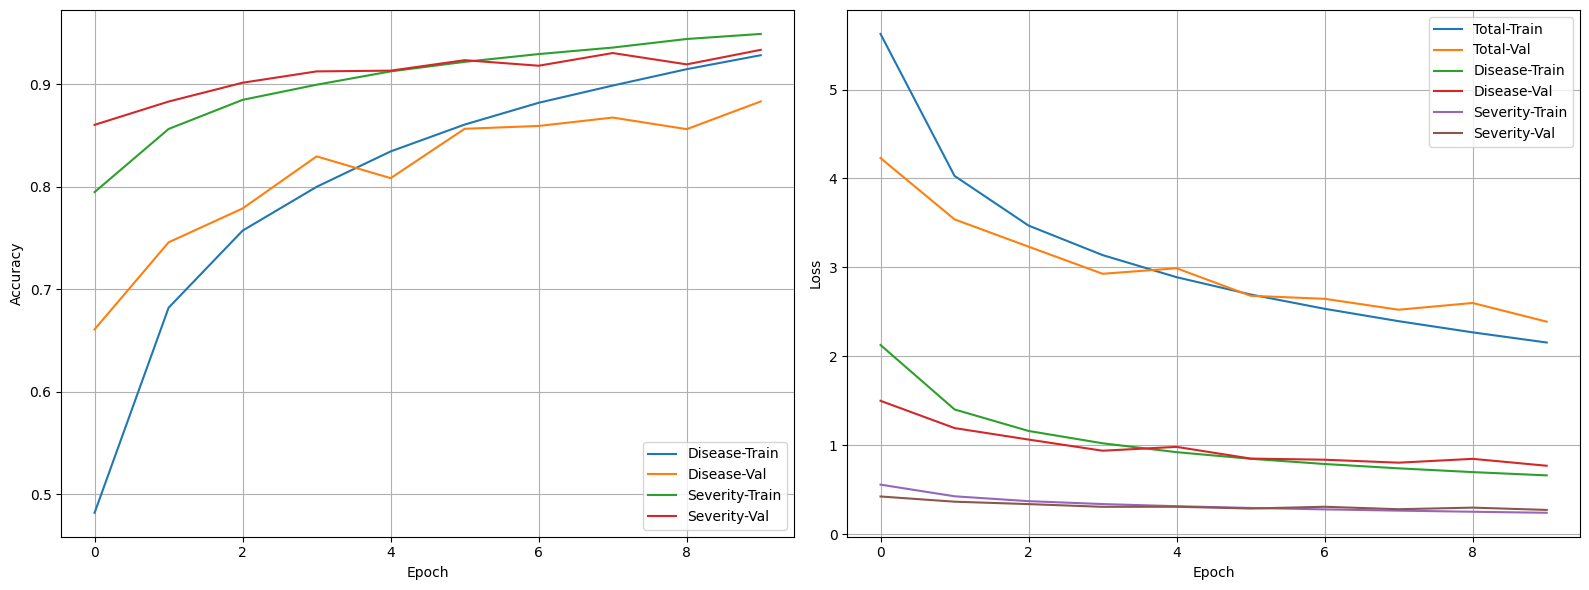

In [17]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(resnet50_history.history['disease_output_accuracy'])
plt.plot(resnet50_history.history['val_disease_output_accuracy'])
plt.plot(resnet50_history.history['severity_output_accuracy'])
plt.plot(resnet50_history.history['val_severity_output_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Disease-Train', 'Disease-Val', 'Severity-Train', 'Severity-Val'])
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(resnet50_history.history['loss'])
plt.plot(resnet50_history.history['val_loss'])
plt.plot(resnet50_history.history['disease_output_loss'])
plt.plot(resnet50_history.history['val_disease_output_loss'])
plt.plot(resnet50_history.history['severity_output_loss'])
plt.plot(resnet50_history.history['val_severity_output_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Total-Train', 'Total-Val', 'Disease-Train', 'Disease-Val', 'Severity-Train', 'Severity-Val'])
plt.grid()

plt.tight_layout()
plt.show()


In [18]:
import pandas as pd
import numpy as np
import cv2
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical

df = pd.read_csv('/content/plant_disease_severity.csv')

disease_encoder = LabelEncoder()
df['disease_label'] = disease_encoder.fit_transform(df['disease'])

severity_encoder = LabelEncoder()
df['severity_label'] = severity_encoder.fit_transform(df['severity'])

train_data, temp_data = train_test_split(df, test_size=0.3, stratify=df['disease_label'], random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, stratify=temp_data['disease_label'], random_state=42)

def preprocess_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (256, 256))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0
    return np.expand_dims(img, axis=0)

X_test = np.array([preprocess_image(p)[0] for p in test_data['image_path']])
y_true_disease = np.array(test_data['disease_label'])
y_true_severity = np.array(test_data['severity_label'])

y_test_disease_cat = to_categorical(y_true_disease, num_classes=len(disease_encoder.classes_))
y_test_severity_cat = to_categorical(y_true_severity, num_classes=len(severity_encoder.classes_))

resnet50_model = load_model('/content/resnet50_finetuned.keras')

results = resnet50_model.evaluate(X_test, [y_test_disease_cat, y_test_severity_cat], verbose=0)
print(f"Disease Test Accuracy:  {results[3]:.4f}")
print(f"Severity Test Accuracy: {results[4]:.4f}")

disease_preds, severity_preds = resnet50_model.predict(X_test, verbose=0)
y_pred_disease = np.argmax(disease_preds, axis=1)
y_pred_severity = np.argmax(severity_preds, axis=1)

print("Disease Classification Report:")
print(classification_report(y_true_disease, y_pred_disease, target_names=disease_encoder.classes_))

print("Severity Classification Report:")
print(classification_report(y_true_severity, y_pred_severity, target_names=severity_encoder.classes_))


Disease Test Accuracy:  0.8783
Severity Test Accuracy: 0.9348
Disease Classification Report:
                                               precision    recall  f1-score   support

                           Apple___Apple_scab       0.62      0.74      0.68        94
                            Apple___Black_rot       0.85      0.81      0.83        93
                     Apple___Cedar_apple_rust       0.76      0.71      0.73        41
                              Apple___healthy       0.77      0.89      0.83       247
                    Background_without_leaves       0.95      0.93      0.94       171
                          Blueberry___healthy       0.91      0.98      0.94       226
                      Cherry___Powdery_mildew       0.95      0.90      0.93       158
                             Cherry___healthy       0.95      0.94      0.94       128
   Corn___Cercospora_leaf_spot Gray_leaf_spot       0.77      0.61      0.68        77
                           Corn___Co

In [19]:
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy


resnet101_base = ResNet101(include_top=False, weights='imagenet', input_shape=(256,256,3))

for layer in resnet101_base.layers[:300]:
    layer.trainable = False
for layer in resnet101_base.layers[300:]:
    layer.trainable = True

features = GlobalAveragePooling2D()(resnet101_base.output)
features = Dropout(0.5)(features)

disease_pred = Dense(
    len(disease_encoder.classes_), activation='softmax',
    kernel_regularizer=regularizers.l2(0.01), name='disease_output')(features)

severity_pred = Dense(
    len(severity_encoder.classes_), activation='softmax',
    kernel_regularizer=regularizers.l2(0.01), name='severity_output')(features)

resnet101_model = Model(inputs=resnet101_base.input, outputs=[disease_pred, severity_pred])

resnet101_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss={
        'disease_output': CategoricalCrossentropy(label_smoothing=0.05),
        'severity_output': CategoricalCrossentropy(label_smoothing=0.03)
    },
    loss_weights={'disease_output': 2.0, 'severity_output': 1.0},
    metrics={'disease_output': 'accuracy', 'severity_output': 'accuracy'}
)

resnet101_model.summary()


171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 42,744,234 (163.06 MB)

 Trainable params: 16,182,826 (61.73 MB)

 Non-trainable params: 26,561,408 (101.32 MB)

In [21]:
resnet101_callbacks = [
    EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
    ModelCheckpoint('resnet101_finetuned.keras', monitor='val_loss', save_best_only=True)
]

resnet101_history = resnet101_model.fit(
    train_loader, validation_data=val_loader,
    epochs=10, callbacks=resnet101_callbacks, verbose=1
)


Epoch 1/10
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 157s 101ms/step - disease_output_accuracy: 0.3315 - disease_output_loss: 2.6930 - loss: 6.8693 - severity_output_accuracy: 0.7383 - severity_output_loss: 0.6646 - val_disease_output_accuracy: 0.6029 - val_disease_output_loss: 1.6317 - val_loss: 4.5035 - val_severity_output_accuracy: 0.8456 - val_severity_output_loss: 0.4358
Epoch 2/10
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 102s 84ms/step - disease_output_accuracy: 0.6031 - disease_output_loss: 1.6434 - loss: 4.5556 - severity_output_accuracy: 0.8364 - severity_output_loss: 0.4697 - val_disease_output_accuracy: 0.6998 - val_disease_output_loss: 1.3160 - val_loss: 3.8314 - val_severity_output_accuracy: 0.8587 - val_severity_output_loss: 0.4148
Epoch 3/10
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 101s 83ms/step - disease_output_accuracy: 0.7003 - disease_output_loss: 1.3422 - loss: 3.8595 - severity_output_accuracy: 0.8676 - severity_output_loss: 0.3962 - val_disease_output_accuracy: 0.7285 - val_disease_output_loss

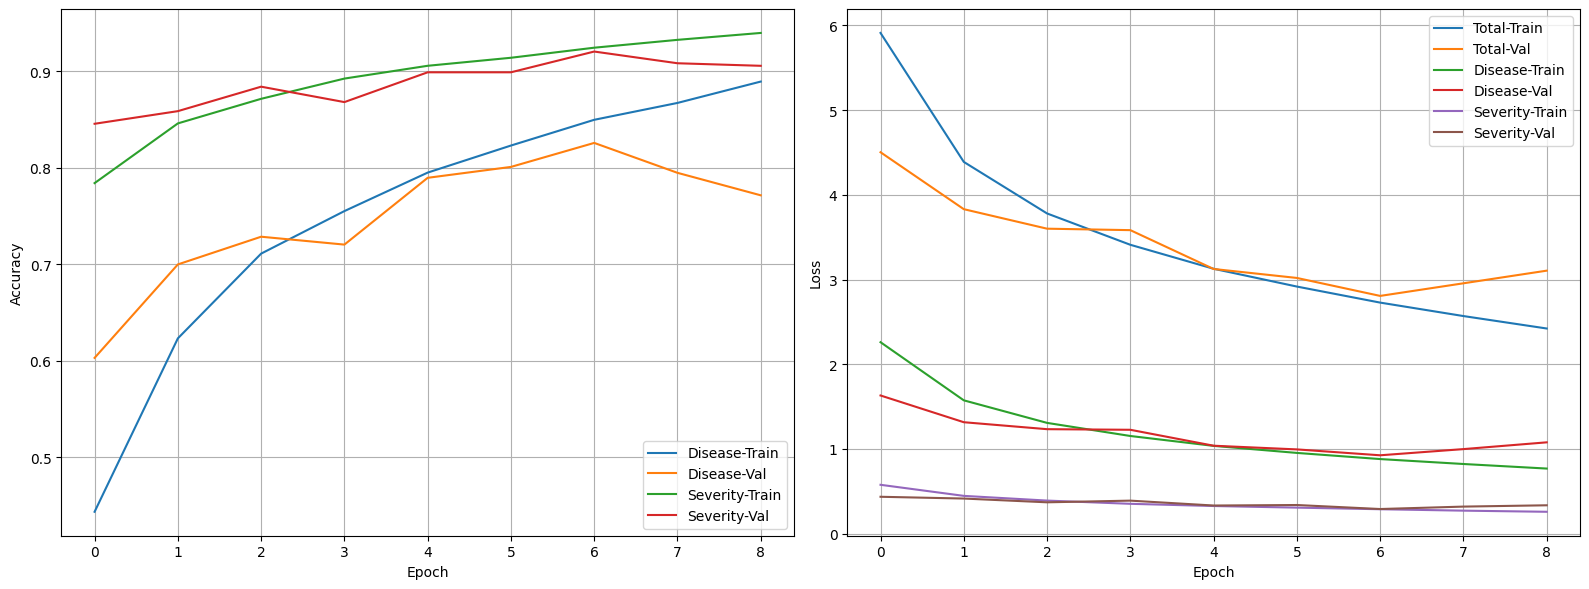

In [22]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(resnet101_history.history['disease_output_accuracy'])
plt.plot(resnet101_history.history['val_disease_output_accuracy'])
plt.plot(resnet101_history.history['severity_output_accuracy'])
plt.plot(resnet101_history.history['val_severity_output_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Disease-Train', 'Disease-Val', 'Severity-Train', 'Severity-Val'])
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(resnet101_history.history['loss'])
plt.plot(resnet101_history.history['val_loss'])
plt.plot(resnet101_history.history['disease_output_loss'])
plt.plot(resnet101_history.history['val_disease_output_loss'])
plt.plot(resnet101_history.history['severity_output_loss'])
plt.plot(resnet101_history.history['val_severity_output_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Total-Train', 'Total-Val', 'Disease-Train', 'Disease-Val', 'Severity-Train', 'Severity-Val'])
plt.grid()

plt.tight_layout()
plt.show()


In [23]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report

X_test = np.array([preprocess_image(p)[0] for p in test_data['image_path']])
y_true_disease = np.array(test_data['disease_label'])
y_true_severity = np.array(test_data['severity_label'])

y_test_disease_cat = to_categorical(y_true_disease, num_classes=len(disease_encoder.classes_))
y_test_severity_cat = to_categorical(y_true_severity, num_classes=len(severity_encoder.classes_))

resnet101_model = load_model('/content/resnet101_finetuned.keras')

results = resnet101_model.evaluate(X_test, [y_test_disease_cat, y_test_severity_cat], verbose=0)
print(f"Disease Test Accuracy:  {results[3]:.4f}")
print(f"Severity Test Accuracy: {results[4]:.4f}")

disease_preds, severity_preds = resnet101_model.predict(X_test, verbose=0)
y_pred_disease = np.argmax(disease_preds, axis=1)
y_pred_severity = np.argmax(severity_preds, axis=1)

print("Disease Classification Report:")
print(classification_report(y_true_disease, y_pred_disease, target_names=disease_encoder.classes_))

print("Severity Classification Report:")
print(classification_report(y_true_severity, y_pred_severity, target_names=severity_encoder.classes_))


Disease Test Accuracy:  0.8192
Severity Test Accuracy: 0.9211
Disease Classification Report:
                                               precision    recall  f1-score   support

                           Apple___Apple_scab       0.64      0.44      0.52        94
                            Apple___Black_rot       0.80      0.75      0.77        93
                     Apple___Cedar_apple_rust       0.82      0.34      0.48        41
                              Apple___healthy       0.88      0.63      0.74       247
                    Background_without_leaves       0.94      0.86      0.90       171
                          Blueberry___healthy       0.80      0.92      0.86       226
                      Cherry___Powdery_mildew       0.76      0.96      0.85       158
                             Cherry___healthy       0.85      0.85      0.85       128
   Corn___Cercospora_leaf_spot Gray_leaf_spot       0.73      0.43      0.54        77
                           Corn___Co

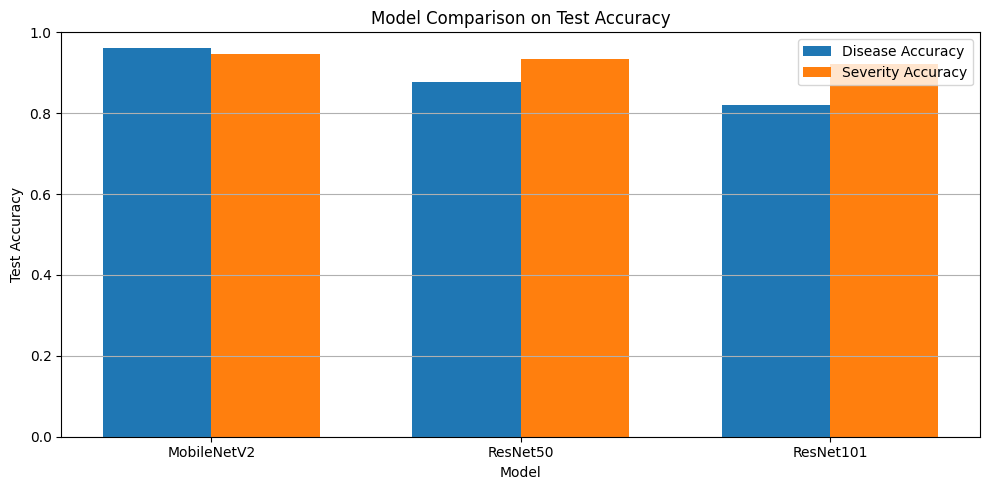

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical

X_test = np.array([preprocess_image(p)[0] for p in test_data['image_path']])
y_true_disease = np.array(test_data['disease_label'])
y_true_severity = np.array(test_data['severity_label'])

y_test_disease_cat = to_categorical(y_true_disease, num_classes=len(disease_encoder.classes_))
y_test_severity_cat = to_categorical(y_true_severity, num_classes=len(severity_encoder.classes_))

mobilenetv2_model = load_model('/content/mobilenetv2_final_model.keras')
mobilenetv2_results = mobilenetv2_model.evaluate(X_test, [y_test_disease_cat, y_test_severity_cat], verbose=0)
mobilenetv2_disease_acc = mobilenetv2_results[3]
mobilenetv2_severity_acc = mobilenetv2_results[4]

resnet50_model = load_model('/content/resnet50_finetuned.keras')
resnet50_results = resnet50_model.evaluate(X_test, [y_test_disease_cat, y_test_severity_cat], verbose=0)
resnet50_disease_acc = resnet50_results[3]
resnet50_severity_acc = resnet50_results[4]

resnet101_model = load_model('/content/resnet101_finetuned.keras')
resnet101_results = resnet101_model.evaluate(X_test, [y_test_disease_cat, y_test_severity_cat], verbose=0)
resnet101_disease_acc = resnet101_results[3]
resnet101_severity_acc = resnet101_results[4]

models = ['MobileNetV2', 'ResNet50', 'ResNet101']

disease_accuracies = [
    mobilenetv2_disease_acc,
    resnet50_disease_acc,
    resnet101_disease_acc
]

severity_accuracies = [
    mobilenetv2_severity_acc,
    resnet50_severity_acc,
    resnet101_severity_acc
]

x = range(len(models))
bar_width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x, disease_accuracies, width=bar_width, label='Disease Accuracy')
plt.bar([p + bar_width for p in x], severity_accuracies, width=bar_width, label='Severity Accuracy')

plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.title('Model Comparison on Test Accuracy')
plt.xticks([p + bar_width / 2 for p in x], models)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [28]:
from tensorflow.keras.models import load_model
import pickle

model = load_model("mobilenetv2_final_model.keras")

with open("mobilenetv2_metadata.pkl", "rb") as f:
    meta = pickle.load(f)

print(meta["disease_classes"])
print(meta["severity_classes"])


['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Background_without_leaves', 'Blueberry___healthy', 'Cherry___Powdery_mildew', 'Cherry___healthy', 'Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___Northern_Leaf_Blight', 'Corn___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl

In [29]:
def preprocess_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (256, 256))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)/255.0
    return np.expand_dims(img, axis=0)

def predict_image(path):
    image = preprocess_image(path)
    disease_pred, severity_pred = model.predict(image)
    disease = meta["disease_classes"][np.argmax(disease_pred)]
    severity = meta["severity_classes"][np.argmax(severity_pred)]
    return disease, severity

img_path = '/content/plant_leaf_disease_dataset/Plant_leave_diseases_dataset_without_augmentation/Potato___Early_blight/image (1).JPG'
result = predict_image(img_path)
print(result)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
('Potato___Early_blight', 'Severe')
